# Perceptron animation

In [12]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Preparing a toy dataset

In [13]:
from google.colab import files
files.upload()  # click the button, select your .txt file

Saving perceptron_toydata.txt to perceptron_toydata (1).txt


{'perceptron_toydata (1).txt': b'0.77\t-1.14\t0\n-0.33\t1.44\t0\n0.91\t-3.07\t0\n-0.37\t-1.91\t0\n-1.84\t-1.13\t0\n-1.50\t0.34\t0\n-0.63\t-1.53\t0\n-1.08\t-1.23\t0\n0.39\t-1.99\t0\n-1.26\t-2.90\t0\n-5.27\t-0.78\t0\n-0.49\t-2.74\t0\n1.48\t-3.74\t0\n-1.64\t-1.96\t0\n0.45\t0.36\t0\n-1.48\t-1.17\t0\n-2.94\t-4.47\t0\n-2.19\t-1.48\t0\n0.02\t-0.02\t0\n-2.24\t-2.12\t0\n-3.17\t-3.69\t0\n-4.09\t1.03\t0\n-2.41\t-2.31\t0\n-3.45\t-0.61\t0\n-3.96\t-2.00\t0\n-2.95\t-1.16\t0\n-2.42\t-3.35\t0\n-1.74\t-1.10\t0\n-1.61\t-1.28\t0\n-2.59\t-2.21\t0\n-2.64\t-2.20\t0\n-2.84\t-4.12\t0\n-1.45\t-2.26\t0\n-3.98\t-1.05\t0\n-2.97\t-1.63\t0\n-0.68\t-1.52\t0\n-0.10\t-3.43\t0\n-1.14\t-2.66\t0\n-2.92\t-2.51\t0\n-2.14\t-1.62\t0\n-3.33\t-0.44\t0\n-1.05\t-3.85\t0\n0.38\t0.95\t0\n-0.05\t-1.95\t0\n-3.20\t-0.22\t0\n-2.26\t0.01\t0\n-1.41\t-0.33\t0\n-1.20\t-0.71\t0\n-1.69\t0.80\t0\n-1.52\t-1.14\t0\n3.88\t0.65\t1\n0.73\t2.97\t1\n0.83\t3.94\t1\n1.59\t1.25\t1\n3.92\t3.48\t1\n3.87\t2.91\t1\n1.14\t3.91\t1\n1.73\t2.80\t1\n2.95\t1.84\

In [14]:
##########################
### DATASET
##########################

data = np.genfromtxt('perceptron_toydata.txt', delimiter='\t')
X, y = data[:, :2], data[:, 2]
y = y.astype(int)

print('Class label counts:', np.bincount(y))
print('X.shape:', X.shape)
print('y.shape:', y.shape)

# Shuffling & train/test split
shuffle_idx = np.arange(y.shape[0])
shuffle_rng = np.random.RandomState(123)
shuffle_rng.shuffle(shuffle_idx)
X, y = X[shuffle_idx], y[shuffle_idx]

Class label counts: [50 50]
X.shape: (100, 2)
y.shape: (100,)


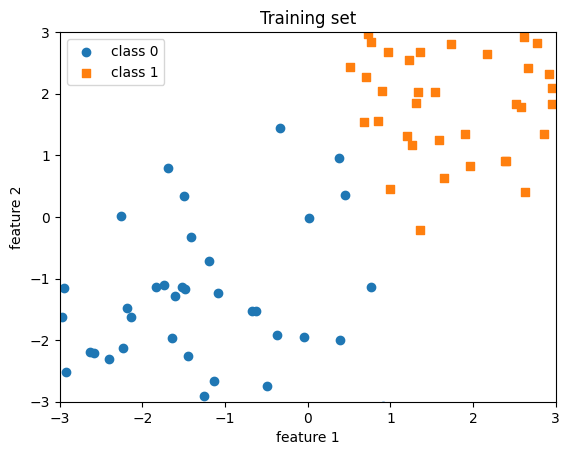

In [15]:
plt.scatter(X[y==0, 0], X[y==0, 1], label='class 0', marker='o')
plt.scatter(X[y==1, 0], X[y==1, 1], label='class 1', marker='s')
plt.title('Training set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()

## Defining the Perceptron model

In [16]:
class Perceptron():
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros((num_features, 1), dtype=float)
        self.bias = np.zeros(1, dtype=float)

    def forward(self, x):
        linear = np.dot(x, self.weights) + self.bias
        predictions = np.where(linear > 0., 1, 0)
        return predictions

    def backward(self, x, y):
        predictions = self.forward(x)
        errors = y - predictions
        return errors

    def train(self, x, y, epochs):
        for e in range(epochs):

            for i in range(y.shape[0]):
                errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
                self.weights += (errors * x[i]).reshape(self.num_features, 1)
                self.bias += errors

    def evaluate(self, x, y):
        predictions = self.forward(x).reshape(-1)
        accuracy = np.sum(predictions == y) / y.shape[0]
        return accuracy

## Training the Perceptron

In [17]:
all_weights = []
all_biases = []

ppn = Perceptron(num_features=2)

acc = 0

for epoch in range(10):

    for i in range(X.shape[0]):

        all_weights.append(ppn.weights.copy())
        all_biases.append(ppn.bias.copy())
        ppn.train(X[i].reshape(1, -1), y[i].reshape(-1), epochs=1)

        acc = ppn.evaluate(X, y)

        if acc == 1.0:
            break

    if acc == 1.0:
        all_weights.append(ppn.weights.copy())
        all_biases.append(ppn.bias.copy())
        break

## Plotting the boundary

/tmp/ipykernel_21315/1549608254.py:22: RuntimeWarning: invalid value encountered in divide
  y_min = ( (-(w[0] * x_min) - b[0])
/tmp/ipykernel_21315/1549608254.py:26: RuntimeWarning: invalid value encountered in divide
  y_max = ( (-(w[0] * x_max) - b[0])
/tmp/ipykernel_21315/1549608254.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


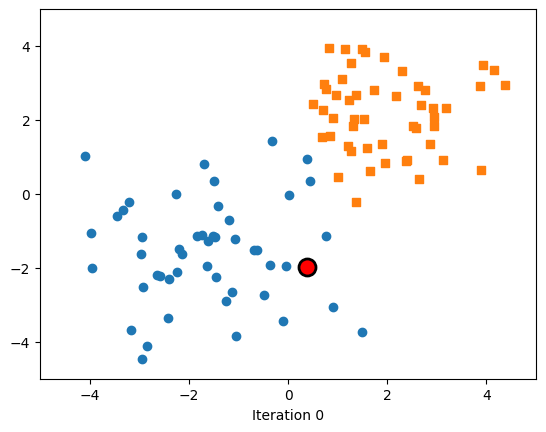

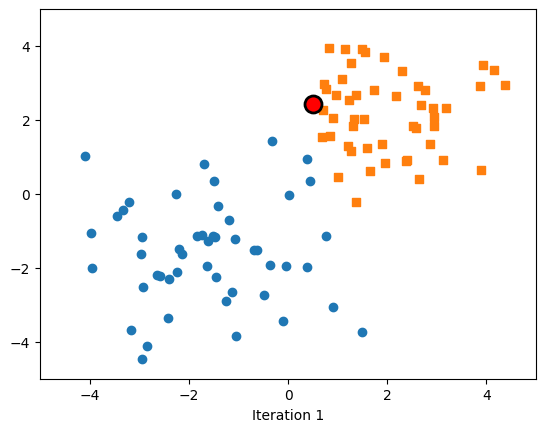

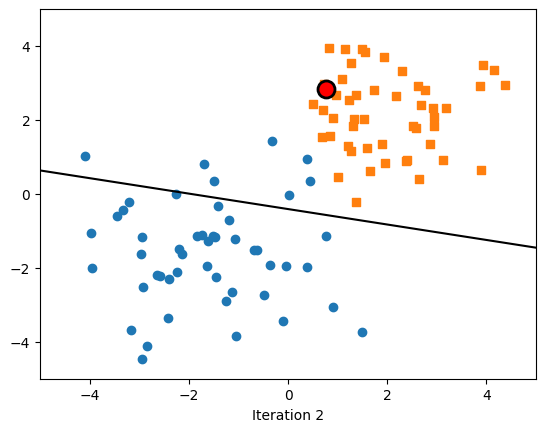

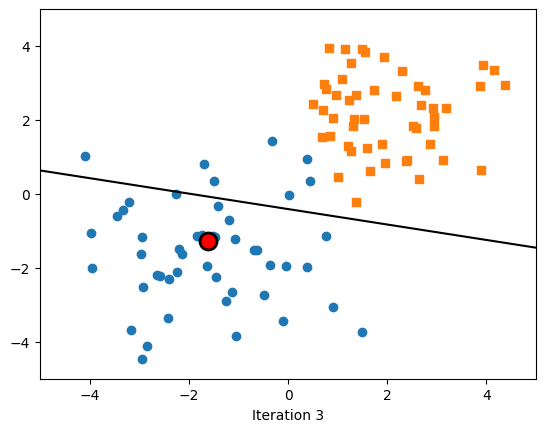

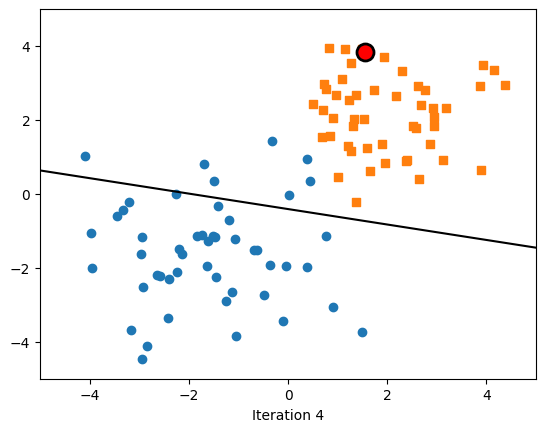

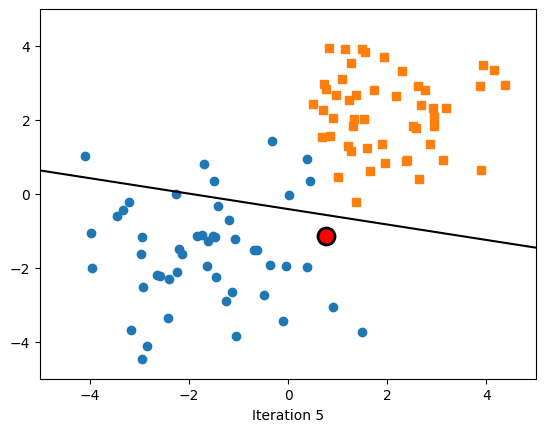

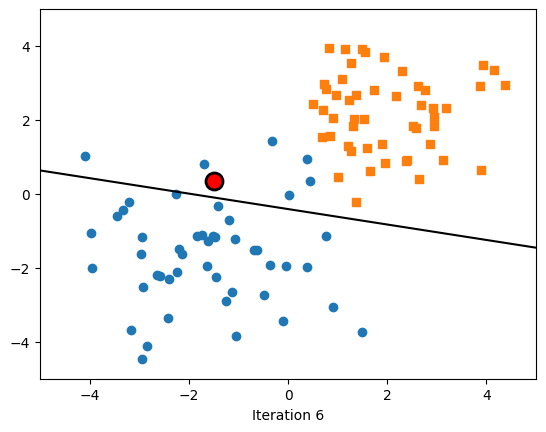

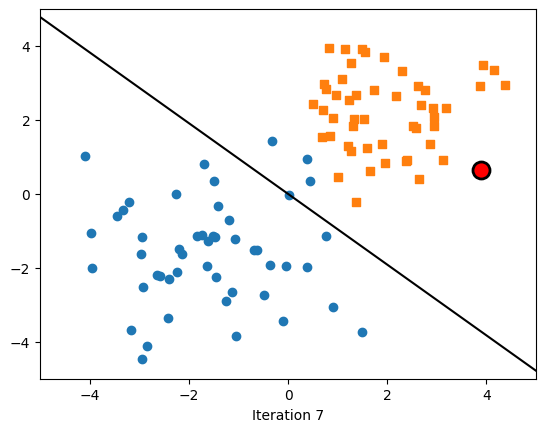

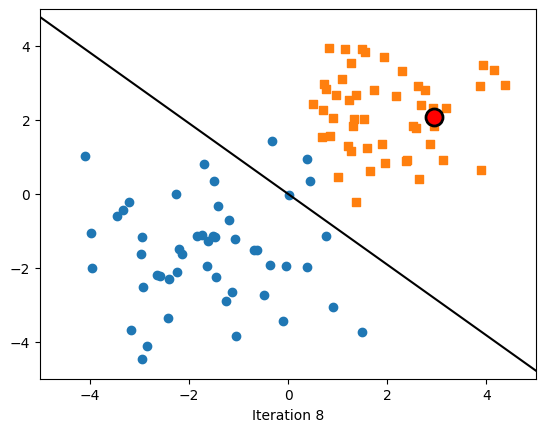

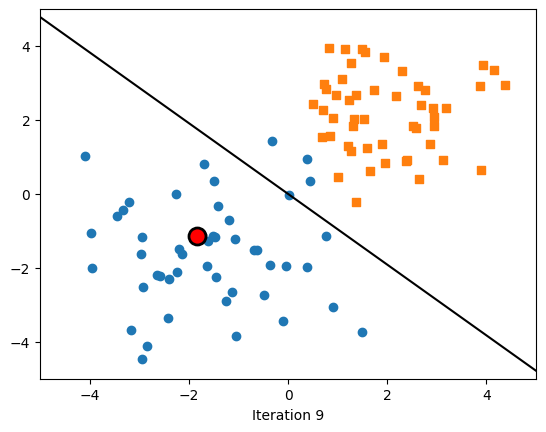

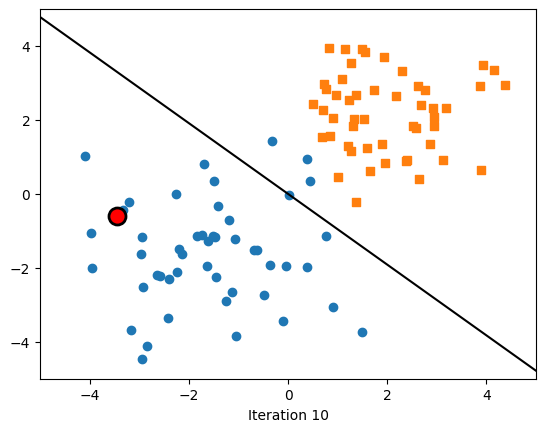

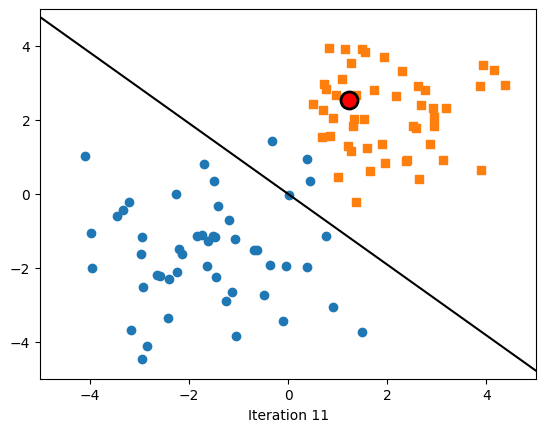

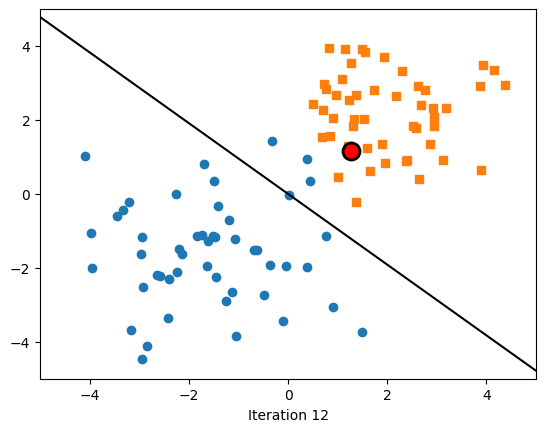

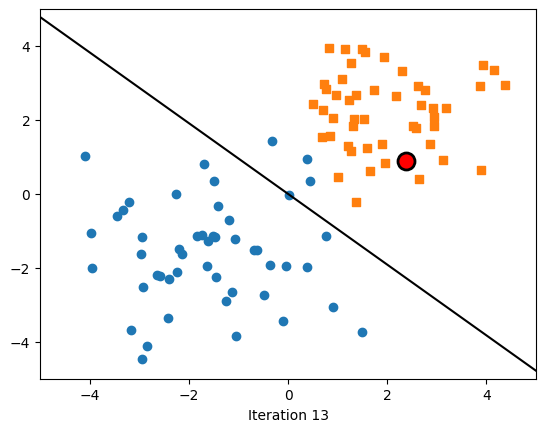

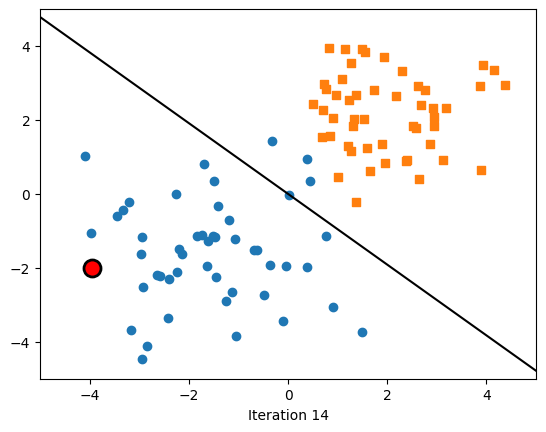

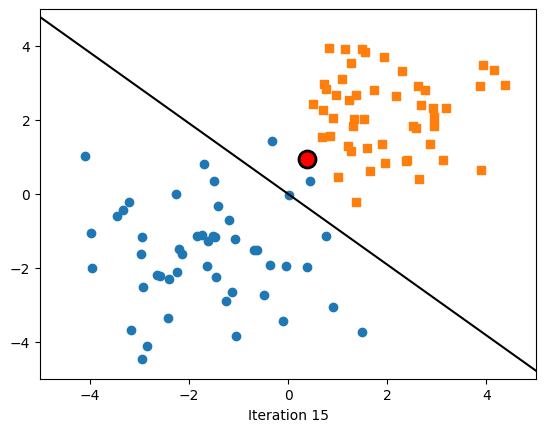

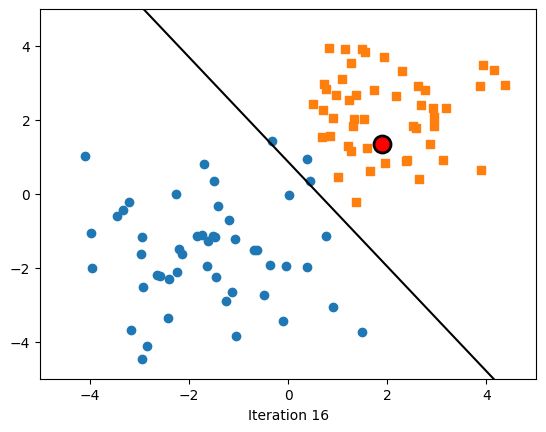

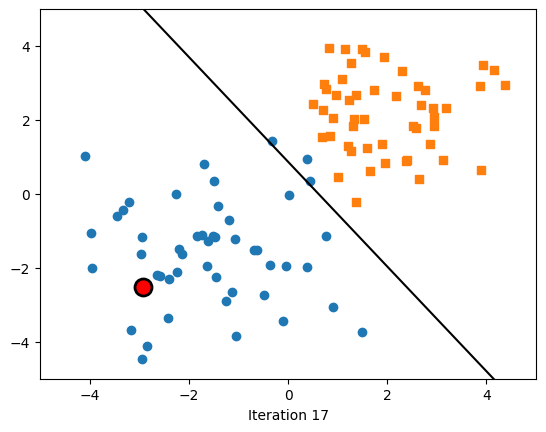

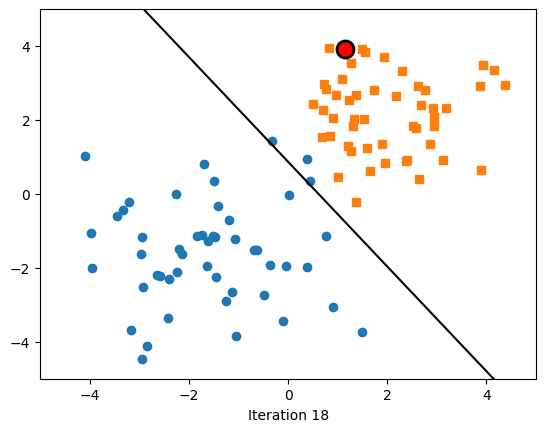

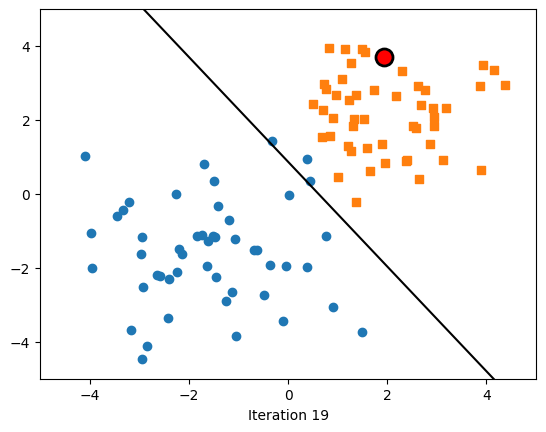

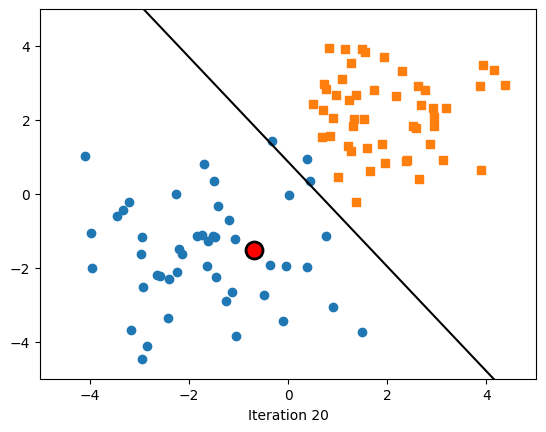

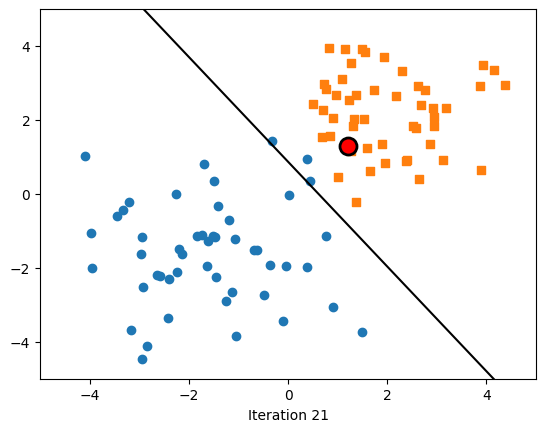

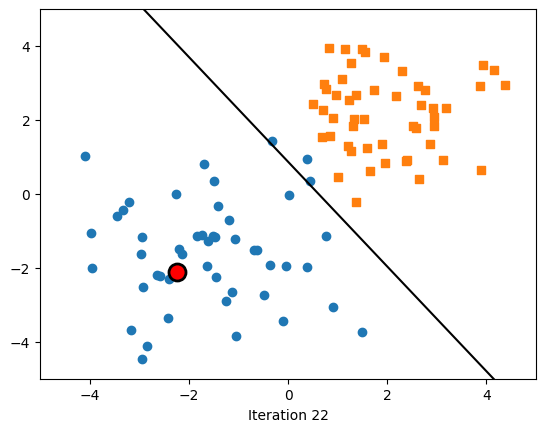

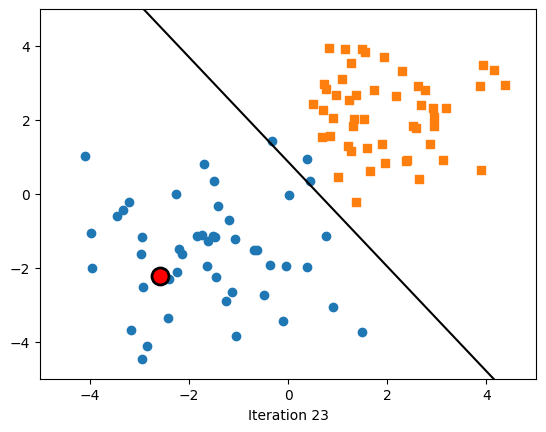

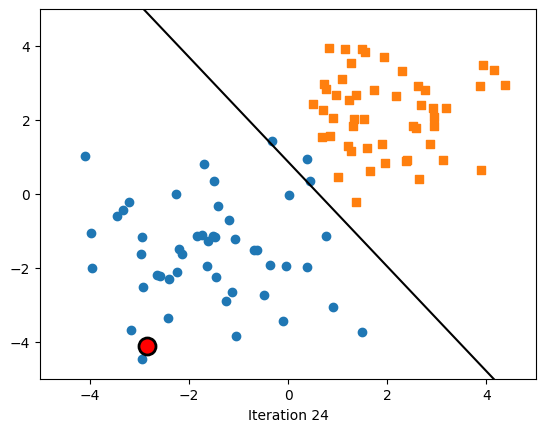

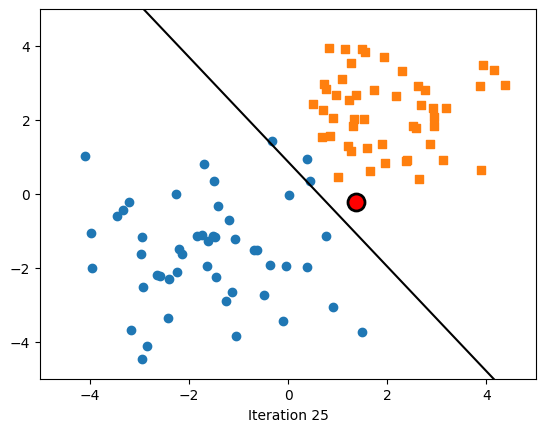

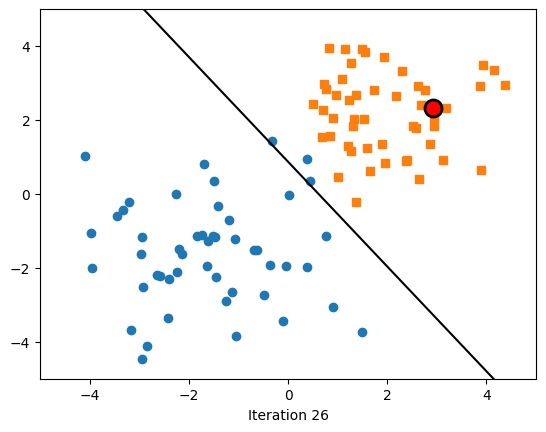

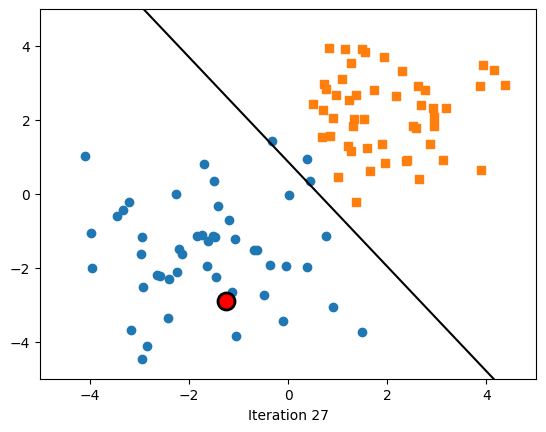

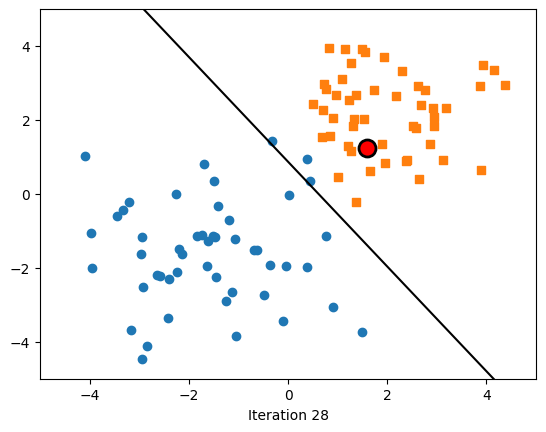

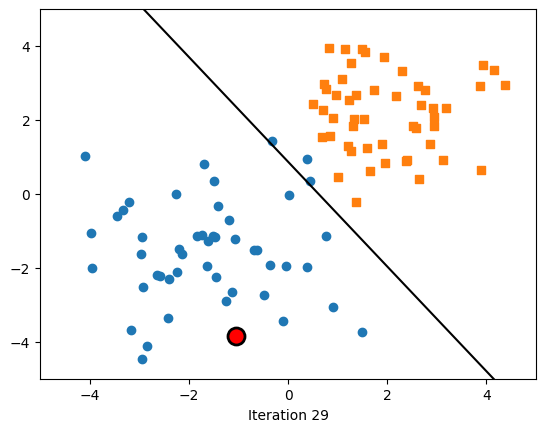

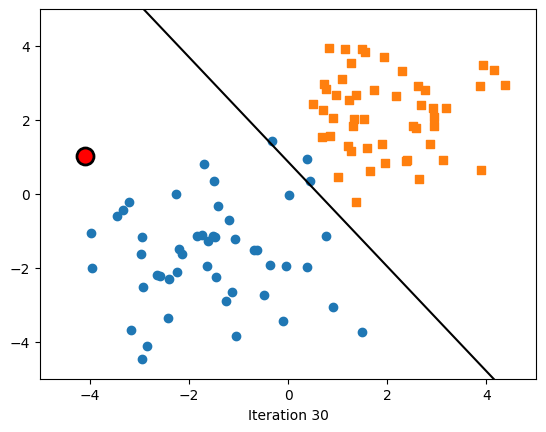

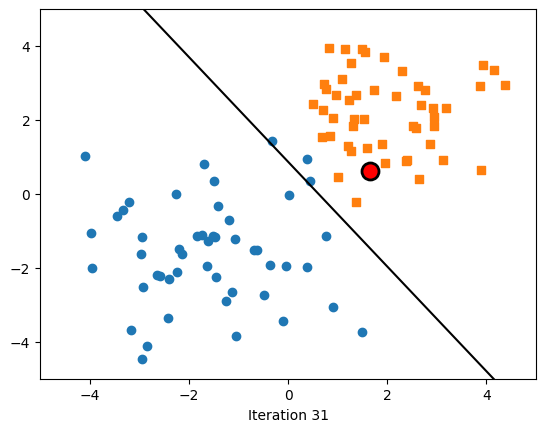

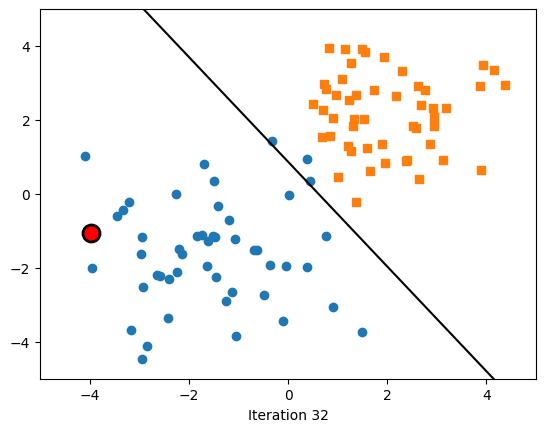

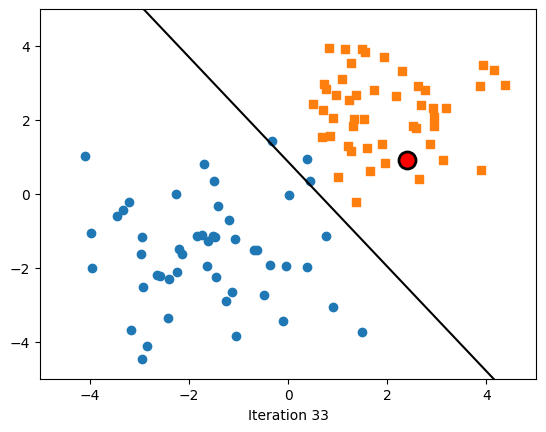

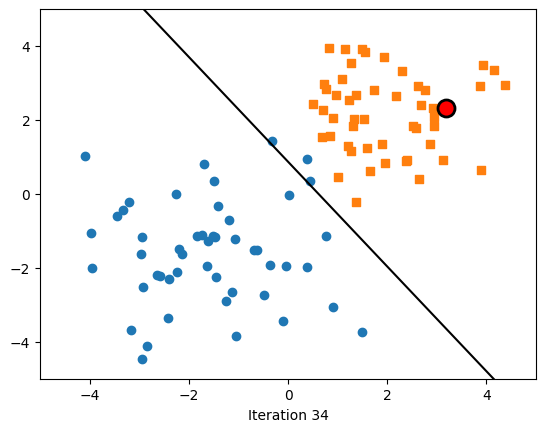

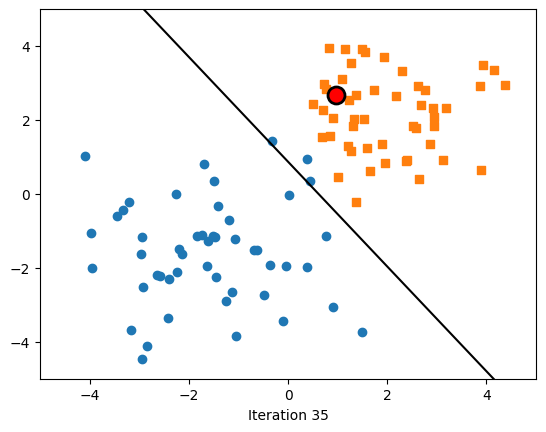

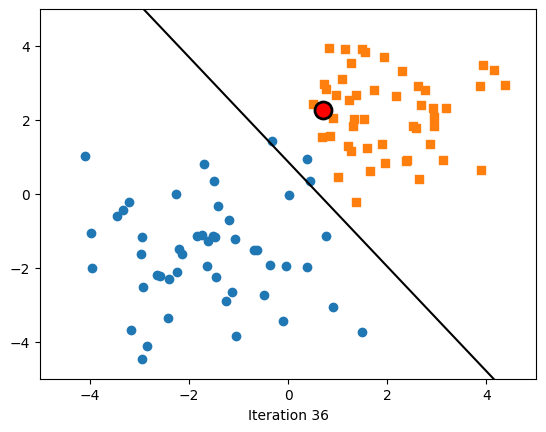

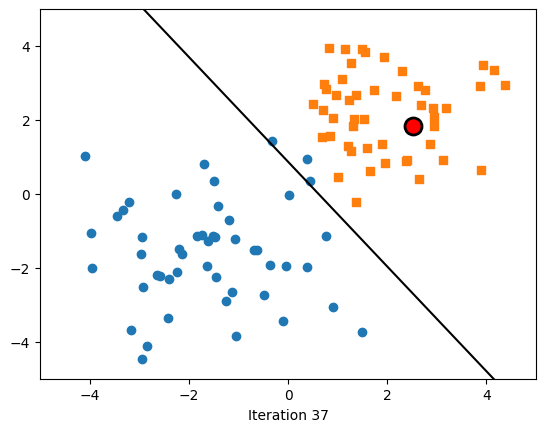

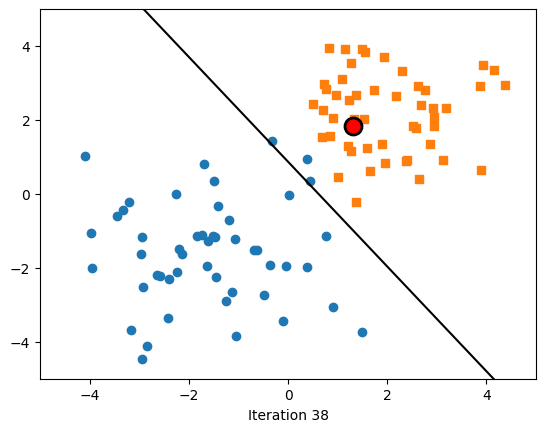

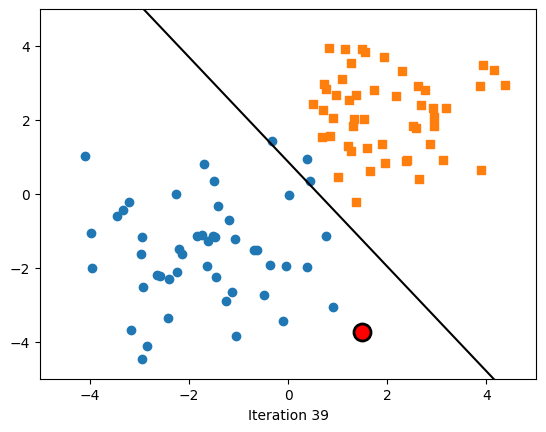

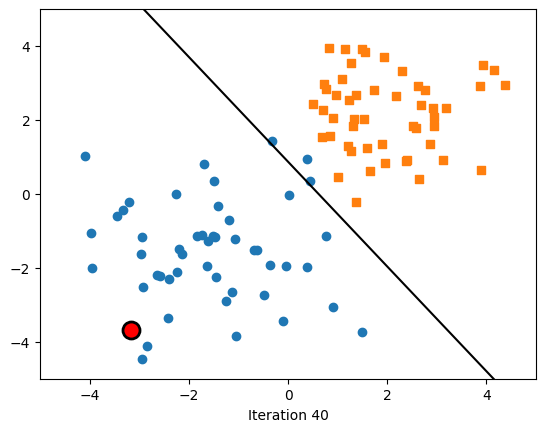

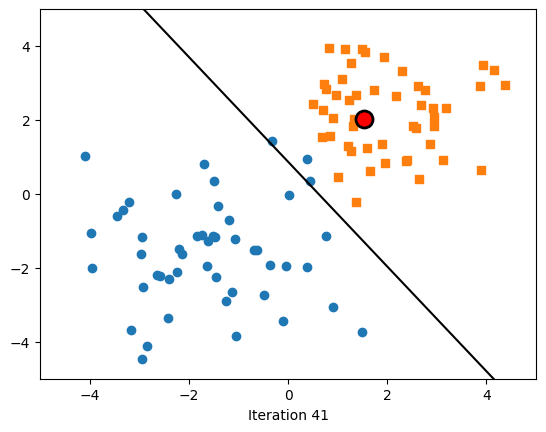

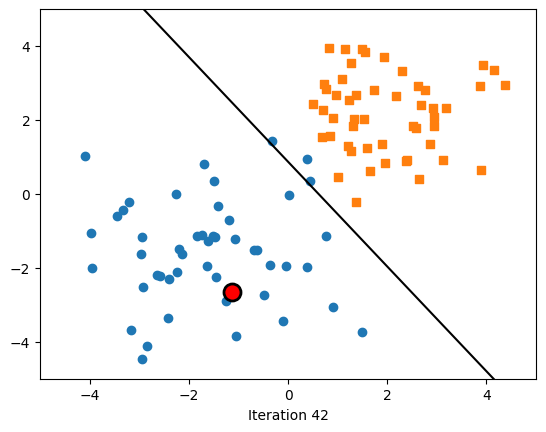

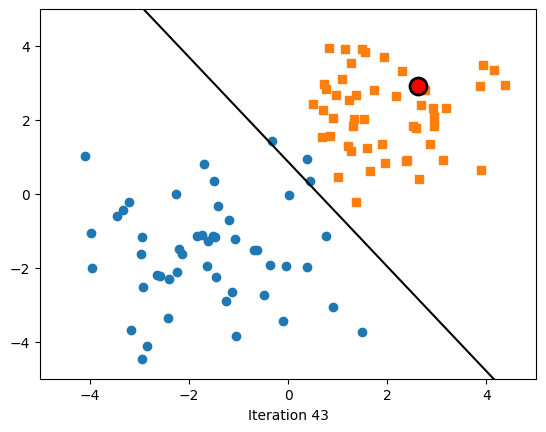

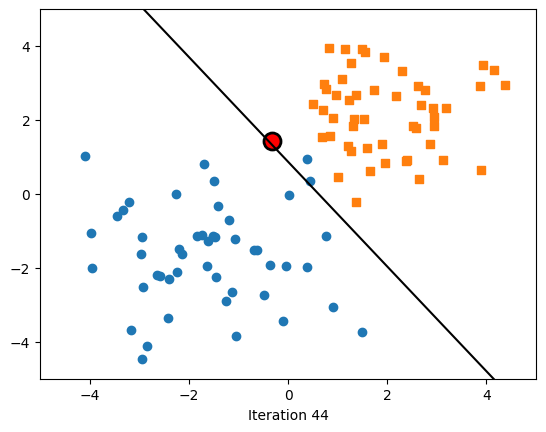

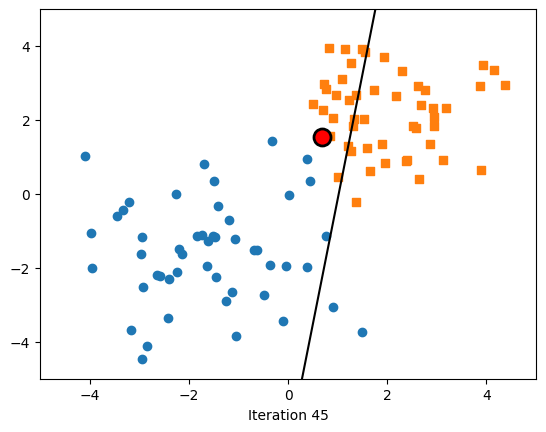

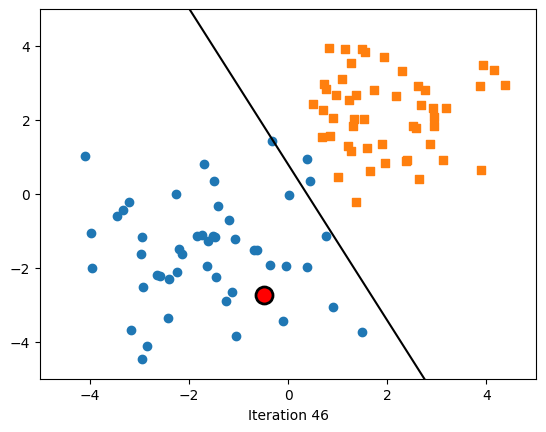

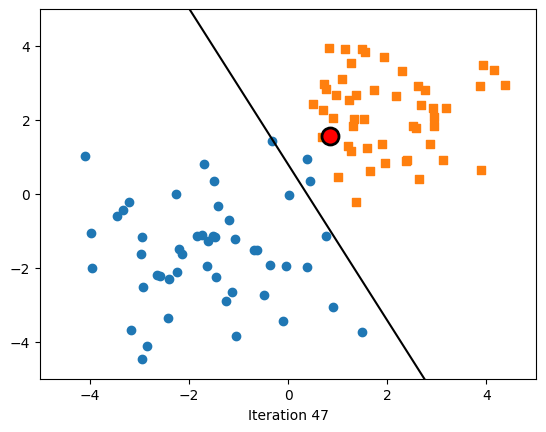

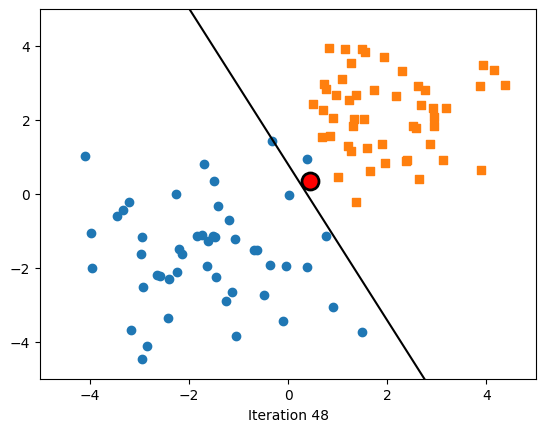

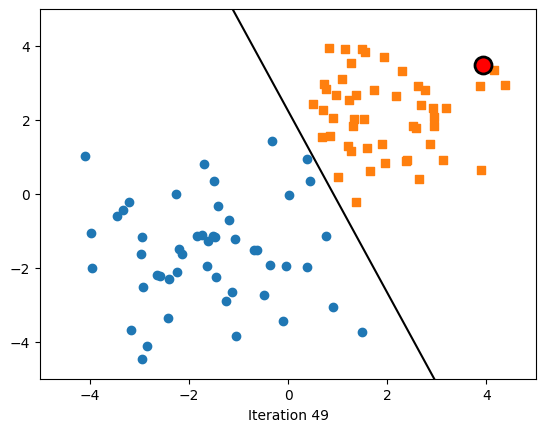

In [20]:
##########################
### 2D Decision Boundary
##########################


import imageio


scatter_highlight_defaults = {'c': 'r',
                              'edgecolor': 'k',
                              'alpha': 1.0,
                              'linewidths': 2,
                              'marker': 'o',
                              's': 150}

def plot(i):

    fig, ax = plt.subplots()
    w, b = all_weights[i], all_biases[i]

    x_min = -20
    y_min = ( (-(w[0] * x_min) - b[0])
              / w[1] )

    x_max = 20
    y_max = ( (-(w[0] * x_max) - b[0])
              / w[1] )

    ax.set_xlim([-5., 5])
    ax.set_ylim([-5., 5])

    ax.set_xlabel('Iteration %d' % i)

    ax.plot([x_min, x_max], [y_min, y_max], color='k')

    ax.scatter(X[y==0, 0], X[y==0, 1], label='class 0', marker='o')
    ax.scatter(X[y==1, 0], X[y==1, 1], label='class 1', marker='s')

    ax.scatter(X[i][0], X[i][1], **scatter_highlight_defaults)

    fig.canvas.draw();
    image = np.frombuffer(fig.canvas.buffer_rgba(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (4,))

    return image


kwargs_write = {'fps':1.0, 'quantizer':'nq'}
imageio.mimsave('training.gif', [plot(i) for i in range(len(all_weights))], fps=1);
